
# Targeting Demand-Response Incentives with CATE Estimation

**A practical project based on *Causal Inference in Python*, Chapter 6 — "Effect Heterogeneity"**

## The business problem

You work for an electric utility. Every summer, peak demand on hot afternoons strains the
grid and forces the utility to fire up expensive (and dirty) "peaker" power plants — or buy
emergency power on the spot market. One lever utilities have is a **demand-response
program**: pay households a cash incentive to cut their electricity usage during peak hours
(e.g., pre-cool the house, delay running the dryer, raise the thermostat a few degrees).

The utility ran a **randomized pilot**: a random incentive amount (\$0–\$40) was offered to
a sample of households for a peak event, and the utility measured how much each household's
usage dropped relative to their normal peak-hour baseline.

A single **average** effect ("$1 of incentive buys X kWh of reduction, on average") is
useful for deciding whether the program is worth running at all. But it hides something
important: **some households can respond far more than others** — a large house with central
AC and a smart thermostat can shed a lot of load; a small apartment with window units has
much less to give. Treating everyone the same wastes budget on low-responders and
under-serves high-responders.

This is exactly the CATE (conditional average treatment effect) problem from the chapter,
now applied to energy:

- **ATE** — `E[Y1 - Y0]`: is the demand-response program worth running at all?
- **CATE** — `E[Y1 - Y0 | X]`: *which households* should get incentives, and *how large*
  should each incentive be, given a limited program budget?

In this notebook we will, step by step:

1. Simulate a realistic demand-response pilot dataset (with a **known ground-truth CATE**,
   so we can grade ourselves — impossible with real data, since the individual treatment
   effect is fundamentally unobservable).
2. Show why a plain usage-prediction model is not the same as a load-reduction-sensitivity
   model.
3. Estimate the **ATE** — the average $-per-kWh effectiveness of the program.
4. Estimate the **CATE** with linear regression + treatment-covariate interactions.
5. Benchmark the CATE model against a purely predictive ML model and a random model.
6. Evaluate CATE quality with the tools from the chapter:
   - Effect by model quantile
   - Cumulative effect curve
   - Cumulative gain curve (+ normalized) and its AUC
   - Target transformation + weighted MSE
7. **Use** the CATE model for the decision that actually matters here — a **limited-budget
   allocation problem**: given a fixed number of dollars, which households should be
   enrolled, and how does that compare to enrolling households at random or spreading the
   budget evenly?

Every section explains the *why*, not just the *how*, so you walk away understanding the
reasoning, not just the code.



## 1. Setup


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from toolz import curry

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 2. Simulate the demand-response pilot

One row per **household-event**: a household observed during one peak-demand event (e.g.,
a hot summer afternoon). We simulate a pilot mirroring the chapter's restaurant example, but
for energy:

- `incentive` (the treatment) is a **randomized** dollar amount, \$0–\$40, offered to the
  household for that event — so there's no confounding, and we can focus purely on
  estimation and evaluation, just like the book does.
- The **true sensitivity** to the incentive (kWh reduced per dollar offered) depends on:
  - `home_sqft` — bigger homes have more discretionary load (AC, pool pumps, etc.) to shed.
  - `has_smart_thermostat` — automated pre-cooling makes it much easier to respond.
  - `ac_type` — central air has more flexible load than window units or no AC.
  - `baseline_kwh` — households with high peak-hour baseline usage have more room to cut.
  - `temperature_f` — on milder days, everyone has an easier time cutting a bit;
    on scorching days, only well-equipped homes can still respond meaningfully.
- `kwh_reduction` (the outcome) is generated from a baseline behavioral response plus
  `tau(X) * incentive` plus noise.


In [2]:

n_households = 4000
n_events = 5  # peak events per household over one summer
rows = []

for hh in range(n_households):
    home_sqft = np.random.uniform(600, 3500)
    has_smart_thermostat = np.random.binomial(1, 0.35)
    ac_type = np.random.choice(["central", "window", "none"], p=[0.55, 0.30, 0.15])
    baseline_kwh = (
        1.2 + 0.0025 * home_sqft
        + (2.0 if ac_type == "central" else 0.8 if ac_type == "window" else 0.0)
        + np.random.normal(0, 0.6)
    )
    baseline_kwh = max(baseline_kwh, 0.5)
    for ev in range(n_events):
        rows.append((hh, ev, home_sqft, has_smart_thermostat, ac_type, baseline_kwh))

data = pd.DataFrame(
    rows,
    columns=["household_id", "event_id", "home_sqft", "has_smart_thermostat",
             "ac_type", "baseline_kwh"],
)

# Weather varies by event (shared across households on the same event, plus noise)
event_temp = {ev: np.random.uniform(88, 104) for ev in range(n_events)}
data["temperature_f"] = data["event_id"].map(event_temp) + np.random.normal(0, 1.5, len(data))

# --- Randomized treatment: incentive dollars offered, $0 to $40 ---
data["incentive"] = np.random.uniform(0, 40, len(data))

# --- Ground-truth CATE function tau(X): kWh reduced per $1 of incentive ---
ac_bonus = data["ac_type"].map({"central": 0.055, "window": 0.020, "none": 0.0})
temp_penalty = 0.010 * np.clip(data["temperature_f"] - 95, 0, None)  # scorching days hurt everyone...
temp_penalty_offset = np.where(
    (data["ac_type"] == "central") & (data["has_smart_thermostat"] == 1),
    0.6 * temp_penalty,  # ...except well-equipped homes, who cope much better
    temp_penalty,
)

data["true_tau"] = (
    0.010
    + 0.000012 * data["home_sqft"]
    + 0.045 * data["has_smart_thermostat"]
    + ac_bonus
    + 0.006 * (data["baseline_kwh"] - data["baseline_kwh"].mean())
    - temp_penalty_offset
).clip(lower=0.0)

# --- Outcome model: baseline response + treatment effect + noise ---
data["kwh_reduction"] = (
    0.15
    + 0.05 * data["has_smart_thermostat"]
    + 0.02 * (data["baseline_kwh"] - data["baseline_kwh"].mean())
    + data["true_tau"] * data["incentive"]
    + np.random.normal(0, 0.35, len(data))
).clip(lower=-1)  # allow small negative noise (measurement error), but not absurd values

data["ac_type"] = data["ac_type"].astype("category")
print(data.shape)
data.head()


(20000, 10)


,household_id,event_id,home_sqft,has_smart_thermostat,ac_type,baseline_kwh,temperature_f,incentive,true_tau,kwh_reduction
0,0,0,1686.166345,1,window,5.548288,94.578198,38.855783,0.082231,3.132334
1,0,1,1686.166345,1,window,5.548288,92.100766,12.415633,0.082231,1.579753
2,0,2,1686.166345,1,window,5.548288,90.203717,37.538083,0.082231,2.662413
3,0,3,1686.166345,1,window,5.548288,93.398772,24.514024,0.082231,1.698055
4,0,4,1686.166345,1,window,5.548288,92.796786,19.812348,0.082231,1.570684



## 3. Why prediction is not the answer

Before touching CATE, let's confirm the chapter's core warning in this new setting:
**grouping households by predicted load reduction (`Y`) is not the same as grouping them by
incentive sensitivity (`dY/d$`)**. If we just built a model to predict `kwh_reduction`, would
sorting by its output reliably separate high- from low-responders?


Correlation between raw kWh reduction and true incentive sensitivity: 0.612


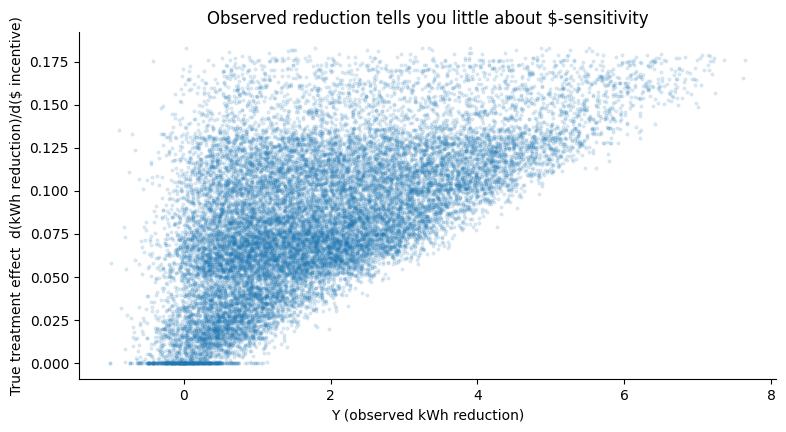

In [3]:

corr = data[["kwh_reduction", "true_tau"]].corr().iloc[0, 1]
print(f"Correlation between raw kWh reduction and true incentive sensitivity: {corr:.3f}")

fig, ax = plt.subplots()
ax.scatter(data["kwh_reduction"], data["true_tau"], s=4, alpha=0.12)
ax.set_xlabel("Y (observed kWh reduction)")
ax.set_ylabel("True treatment effect  d(kWh reduction)/d($ incentive)")
ax.set_title("Observed reduction tells you little about $-sensitivity")
plt.show()



Exactly as in the book: raw outcome level and true treatment sensitivity are, in general,
different things (here the correlation is weak/moderate, muddied by baseline behavioral
differences unrelated to incentive size). A model that predicts `kwh_reduction` well is
**not automatically** a model that tells you who to pay more.

## 4. The ATE: is the demand-response program worth running?

Since `incentive` was randomized, the chapter's simple regression-slope estimator recovers
the ATE without bias — this answers the **program evaluation** question: is the average
kWh-per-dollar return good enough to justify the program at all?


In [4]:

@curry
def effect(data, y, t):
    # Simple regression-slope estimator of the effect of t on y (chapter's `effect` fn).
    return (
        np.sum((data[t] - data[t].mean()) * (data[y] - data[y].mean()))
        / np.sum((data[t] - data[t].mean()) ** 2)
    )

ate = effect(data, "kwh_reduction", "incentive")
print(f"Estimated ATE (kWh reduced per $1 of incentive): {ate:.4f}")
print(f"True average tau in the population:              {data['true_tau'].mean():.4f}")


Estimated ATE (kWh reduced per $1 of incentive): 0.0853
True average tau in the population:              0.0850



That average number is useful for a go/no-go decision on the program overall. But it tells
every household to expect the *same* kWh-per-dollar payoff — which we already know from
`true_tau` is false. Households with central AC, smart thermostats, and big homes can give
back far more per dollar spent. That's the personalization gap CATE is built to close.

## 5. Estimating the CATE with regression + interactions

Following the chapter, we fit

```
kwh_reduction_i = b0 + b1*incentive_i + b2*X_i*incentive_i + b3*X_i + e_i
```

and differentiate with respect to `incentive` to get a *predicted* slope `b1 + b2*X_i` that
varies by household characteristics — a CATE model — even though the true per-household
slope is never directly observed.

Covariates: `home_sqft`, `has_smart_thermostat`, `ac_type`, `baseline_kwh`, `temperature_f`
— the household- and event-level features a utility would actually have on file or could
forecast (weather).


In [5]:

X = ["home_sqft", "has_smart_thermostat", "C(ac_type)", "baseline_kwh", "temperature_f"]
formula = f"kwh_reduction ~ incentive*({'+'.join(X)})"
regr_cate = smf.ols(formula, data=data).fit()

# Predicted slope via finite differences (exact for a linear model; the same trick
# generalizes to any model class).
cate_pred_full = (
    regr_cate.predict(data.assign(incentive=data["incentive"] + 1))
    - regr_cate.predict(data)
)

print("Correlation between CATE prediction and ground truth (full data, in-sample):",
      round(np.corrcoef(cate_pred_full, data["true_tau"])[0, 1], 3))


Correlation between CATE prediction and ground truth (full data, in-sample): 0.994



## 6. Honest evaluation: train/test split

We split by household, not by row, so the same home never appears in both sets (that would
leak information and flatter the model). This mirrors the chapter's chronological split for
the restaurant data — here the analogous "no leakage" boundary is *by household*.


In [6]:

rng = np.random.default_rng(7)
household_ids = data["household_id"].unique()
rng.shuffle(household_ids)
n_train_hh = int(0.7 * len(household_ids))
train_hh = set(household_ids[:n_train_hh])

train = data[data["household_id"].isin(train_hh)]
test = data[~data["household_id"].isin(train_hh)]

regr_model = smf.ols(formula, data=train).fit()

cate_pred = (
    regr_model.predict(test.assign(incentive=test["incentive"] + 1))
    - regr_model.predict(test)
)

print(f"Train rows: {len(train):,}   Test rows: {len(test):,}")


Train rows: 14,000   Test rows: 6,000



## 7. Two benchmarks

As in the chapter, we compare our CATE model against:

- **A purely predictive ML model** (`GradientBoostingRegressor` predicting
  `kwh_reduction` directly, *not* the effect). This is the natural instinct for a data
  scientist — and the whole point of the chapter is that it's the wrong tool here.
- **A random model** that outputs noise. If our CATE model can't beat this, it's worthless.


In [7]:

np.random.seed(1)
X_ml = ["home_sqft", "has_smart_thermostat", "baseline_kwh", "temperature_f", "incentive"]
train_ml = pd.get_dummies(train, columns=["ac_type"], drop_first=True)
test_ml = pd.get_dummies(test, columns=["ac_type"], drop_first=True)
ml_features = X_ml + [c for c in train_ml.columns if c.startswith("ac_type_")]

ml_model = GradientBoostingRegressor(n_estimators=400, random_state=1)
ml_model.fit(train_ml[ml_features], train_ml["kwh_reduction"])
ml_pred = ml_model.predict(test_ml[ml_features])

np.random.seed(123)
rand_pred = np.random.uniform(-1, 1, len(test))

test_pred = test.assign(
    ml_pred=ml_pred,
    cate_pred=cate_pred,
    rand_m_pred=rand_pred,
)
test_pred[["kwh_reduction", "incentive", "true_tau", "ml_pred", "cate_pred", "rand_m_pred"]].head()


,kwh_reduction,incentive,true_tau,ml_pred,cate_pred,rand_m_pred
35,0.039340,39.450190,0.0,-0.000683,-0.007329,0.392938
36,0.087986,12.187905,0.0,0.033928,-0.003013,-0.427721
37,-0.228991,4.356281,0.0,-0.072691,0.003051,-0.546297
38,-0.129609,7.654942,0.0,-0.001106,-0.000031,0.102630
39,-0.458743,17.048854,0.0,-0.029008,-0.009544,0.438938



## 8. Evaluation tool #1 — Effect by model quantile

Since the individual treatment effect is unobservable, we bucket household-events into
quantiles of each model's prediction, and estimate the **group-level** effect (via the same
regression-slope estimator used for the ATE) inside each bucket. A good CATE model produces
a monotonically increasing "staircase."


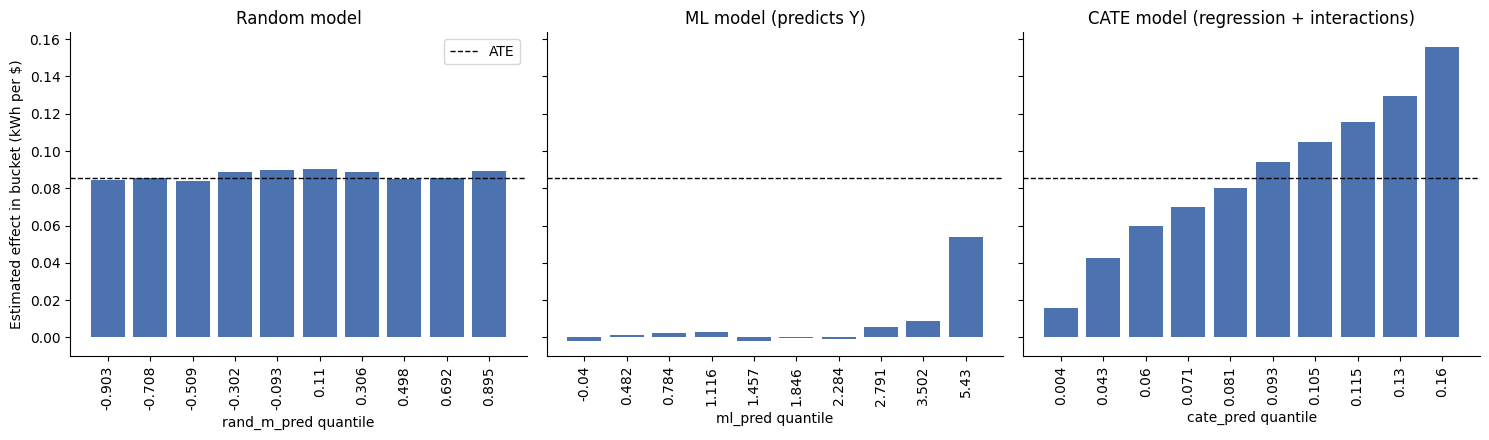

In [8]:

def effect_by_quantile(df, pred, y="kwh_reduction", t="incentive", q=10):
    groups = np.round(pd.IntervalIndex(pd.qcut(df[pred], q=q, duplicates="drop")).mid, 3)
    return (
        df.assign(**{f"{pred}_quantile": groups})
          .groupby(f"{pred}_quantile", observed=True)
          .apply(effect(y=y, t=t), include_groups=False)
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, col, title in zip(
    axes,
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["Random model", "ML model (predicts Y)", "CATE model (regression + interactions)"],
):
    eq = effect_by_quantile(test_pred, col)
    ax.bar(range(len(eq)), eq.values, color="#4C72B0")
    ax.axhline(ate, color="black", linestyle="--", linewidth=1, label="ATE")
    ax.set_xticks(range(len(eq)))
    ax.set_xticklabels(eq.index, rotation=90)
    ax.set_title(title)
    ax.set_xlabel(f"{col} quantile")
axes[0].set_ylabel("Estimated effect in bucket (kWh per $)")
axes[0].legend()
plt.tight_layout()
plt.show()



Same interpretation as the chapter: the random model hovers flat around the ATE — useless
for targeting. The ML model may show *some* structure, but not a reliable ordering. The
CATE model should show a clean staircase — proof it separates high- and low-responding
households.

## 9. Evaluation tool #2 — Cumulative effect curve

Sort household-events by the model's prediction and **accumulate**: estimate the effect on
the top 1% most-sensitive households, then top 2%, ..., up to 100%. A good model starts high
and decays smoothly to the ATE.


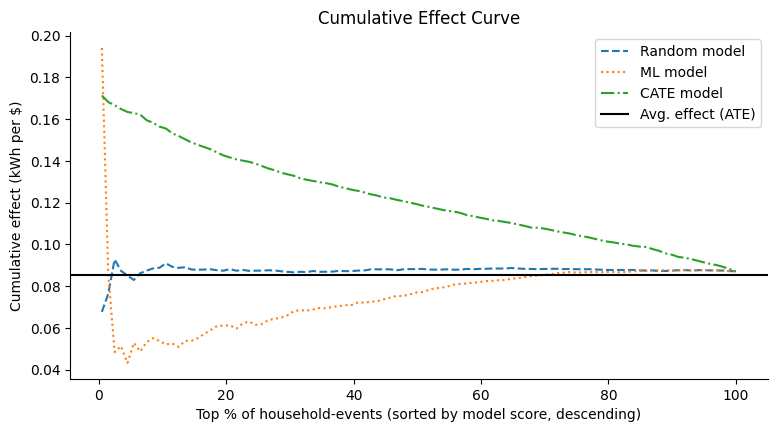

In [9]:

def cumulative_effect_curve(dataset, prediction, y="kwh_reduction", t="incentive",
                             min_rows=30, steps=100):
    size = len(dataset)
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(min_rows, size, steps).astype(int)
    return np.array([effect(ordered_df.head(rows), y, t) for rows in n_rows]), n_rows

fig, ax = plt.subplots()
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    curve, n_rows = cumulative_effect_curve(test_pred, col)
    ax.plot(100 * n_rows / len(test_pred), curve, style, label=label)

ax.axhline(ate, color="black", linewidth=1.5, label="Avg. effect (ATE)")
ax.set_xlabel("Top % of household-events (sorted by model score, descending)")
ax.set_ylabel("Cumulative effect (kWh per $)")
ax.set_title("Cumulative Effect Curve")
ax.legend()
plt.show()



## 10. Evaluation tool #3 — Cumulative gain curve (+ normalized) and AUC

The cumulative effect curve over-weights its earliest (noisiest, smallest-sample) points.
The chapter's fix: multiply each point by the cumulative sample fraction `N_cum/N` to get
the **cumulative gain curve**, then normalize and reduce it to a single AUC number for
automated model comparison.


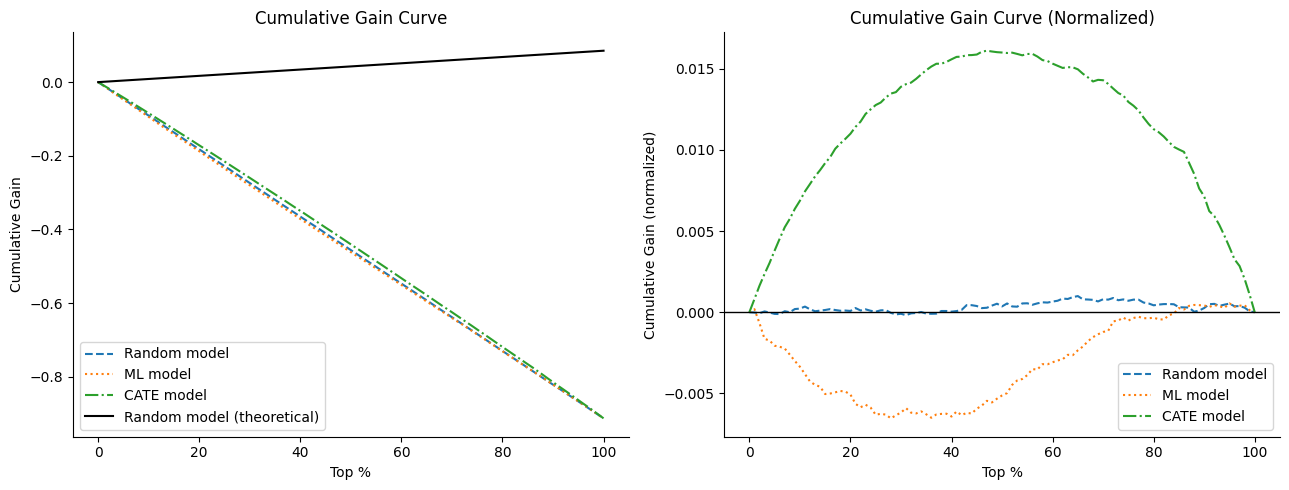

AUC for rand_m_pred: 0.03
AUC for ml_pred: -0.31
AUC for cate_pred: 1.13


In [10]:

def cumulative_gain_curve(df, prediction, y="kwh_reduction", t="incentive",
                           steps=100, normalize=True):
    effect_fn = effect(y=y, t=t)
    normalizer = effect_fn(df) if normalize else 1.0
    size = len(df)
    ordered_df = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(size / steps, size, steps).astype(int)
    gains = [
        (effect_fn(ordered_df.head(rows)) - normalizer) * (rows / size)
        for rows in n_rows
    ]
    return np.array([0] + gains), np.array([0] + list(100 * n_rows / size))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
aucs = {}
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    gain, pct = cumulative_gain_curve(test_pred, col, normalize=False)
    gain_n, _ = cumulative_gain_curve(test_pred, col, normalize=True)
    axes[0].plot(pct, gain, style, label=label)
    axes[1].plot(pct, gain_n, style, label=label)
    aucs[col] = gain_n.sum()

axes[0].plot([0, 100], [0, ate], color="black", label="Random model (theoretical)")
axes[0].set_title("Cumulative Gain Curve")
axes[0].set_xlabel("Top %"); axes[0].set_ylabel("Cumulative Gain"); axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Cumulative Gain Curve (Normalized)")
axes[1].set_xlabel("Top %"); axes[1].set_ylabel("Cumulative Gain (normalized)"); axes[1].legend()
plt.tight_layout()
plt.show()

for k, v in aucs.items():
    print(f"AUC for {k}: {v:.2f}")



The bigger the area between the normalized curve and zero, the better the model orders true
CATE. We'd expect `cate_pred` to dominate, `rand_m_pred` to hover near zero, and `ml_pred`
to land somewhere weaker in between.

## 11. Evaluation tool #4 — Target transformation + weighted MSE

The curves above only check **ordering**, not calibration. To probe calibration, we build
the chapter's approximate individual-level target:

```
Y*_i = (Y_i - mu_y(X_i)) / (T_i - mu_t(X_i))
```

which satisfies `E[Y*_i] = tau_i` in expectation, even though we can't observe `tau_i`
directly. We weight by `(T_i - mu_t(X_i))^2` to downweight the noisiest points (where the
denominator is near zero), then compute a weighted MSE against `Y*` for each model.


In [11]:

X_form = "home_sqft + has_smart_thermostat + C(ac_type) + baseline_kwh + temperature_f"
y_res = smf.ols(f"kwh_reduction ~ {X_form}", data=test).fit().resid
t_res = smf.ols(f"incentive ~ {X_form}", data=test).fit().resid
tau_hat = y_res / t_res
weights = t_res ** 2

for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    wmse = mean_squared_error(tau_hat, test_pred[m], sample_weight=weights)
    print(f"Weighted MSE for {m}: {wmse:,.5f}")

# Because we simulated the data, we can go one step further than the book and also check
# calibration against the TRUE tau directly:
print("\n--- Only possible because this is simulated data ---")
for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    corr = np.corrcoef(test_pred[m], test_pred["true_tau"])[0, 1]
    print(f"Correlation of {m} with true_tau: {corr:.3f}")


Weighted MSE for rand_m_pred: 0.35026
Weighted MSE for ml_pred: 6.08081
Weighted MSE for cate_pred: 0.00103

--- Only possible because this is simulated data ---
Correlation of rand_m_pred with true_tau: -0.015
Correlation of ml_pred with true_tau: 0.612
Correlation of cate_pred with true_tau: 0.994



## 12. From CATE to a decision: budget-constrained enrollment

This is the payoff, and it's a slightly different decision than the chapter's continuous
price-optimization example — here we hit the **limited-supply case** the chapter mentions
for binary/scarce treatments: *"If you don't have an unlimited supply of the treatment...
you probably want to treat the top N units, according to some CATE ordering model, provided
that they all have positive effect."*

Concretely: the utility has a **fixed budget** for this peak event (say, \$50,000) and needs
to decide which households to enroll and how large an incentive to offer each. A simple,
practical policy directly implied by the chapter:

1. Rank test households by predicted `tau` (CATE), descending.
2. Walk down the list, giving each household its full incentive budget need only while
   `tau > 0` and dollars remain.
3. Compare against two baselines:
   - **Random enrollment** — pick households at random until the budget runs out.
   - **Flat/ATE enrollment** — spread the exact same total budget evenly across *all*
     households (the "no personalization" policy).

For simplicity we'll fix a \$25 incentive per enrolled household under the CATE and random
policies (so the only difference is *who* gets picked), and evaluate all three policies
against the **true** kWh reduction they would have produced.


In [12]:

budget = 50_000       # total dollars available for this peak event
incentive_per_hh = 25 # $ offered to each enrolled household under CATE/random policies
n_enroll = budget // incentive_per_hh

test_eval = test_pred.copy()

# --- Policy 1: CATE-targeted enrollment (rank by predicted tau, take the top N) ---
cate_ranked = test_eval.sort_values("cate_pred", ascending=False)
cate_enrolled = cate_ranked.head(n_enroll)

# --- Policy 2: Random enrollment (same budget, same $ per household, random selection) ---
rng = np.random.default_rng(99)
random_enrolled = test_eval.sample(n=n_enroll, random_state=99)

# --- Policy 3: Flat/ATE spread -- same total budget, spread evenly (a smaller $ amount
#     to every single household in the test set) ---
flat_incentive = budget / len(test_eval)

def true_reduction(df, incentive_dollars):
    # Uses the TRUE simulated tau to see what would have actually happened --
    # only possible here because we know the ground truth from the simulation.
    # In a real deployment you'd measure this via a holdout / randomized rollout.
    return (0.15 + 0.05 * df["has_smart_thermostat"]
            + 0.02 * (df["baseline_kwh"] - df["baseline_kwh"].mean())
            + df["true_tau"] * incentive_dollars).clip(lower=0)

cate_total_kwh = true_reduction(cate_enrolled, incentive_per_hh).sum()
random_total_kwh = true_reduction(random_enrolled, incentive_per_hh).sum()
flat_total_kwh = true_reduction(test_eval, flat_incentive).sum()

# --- Oracle: rank by the TRUE tau instead of the predicted one -- upper bound ---
oracle_ranked = test_eval.sort_values("true_tau", ascending=False)
oracle_enrolled = oracle_ranked.head(n_enroll)
oracle_total_kwh = true_reduction(oracle_enrolled, incentive_per_hh).sum()

results = pd.DataFrame({
    "policy": ["Random enrollment", "Flat spread (ATE, all households)",
               "CATE-targeted enrollment", "Oracle targeting (upper bound)"],
    "households_reached": [len(random_enrolled), len(test_eval),
                            len(cate_enrolled), len(oracle_enrolled)],
    "total_kwh_reduced": [random_total_kwh, flat_total_kwh,
                           cate_total_kwh, oracle_total_kwh],
})
results["kwh_per_dollar"] = results["total_kwh_reduced"] / budget
results["pct_of_oracle"] = 100 * results["total_kwh_reduced"] / results["total_kwh_reduced"].iloc[-1]
results


,policy,households_reached,total_kwh_reduced,kwh_per_dollar,pct_of_oracle
0,Random enrollment,2000,4699.721982,0.093994,67.687471
1,"Flat spread (ATE, all households)",6000,5354.737246,0.107095,77.121291
2,CATE-targeted enrollment,2000,6934.549204,0.138691,99.874440
3,Oracle targeting (upper bound),2000,6943.267167,0.138865,100.000000



This table is the energy-industry version of the chapter's central lesson: with a **fixed
budget**, targeting enrollment using the CATE model's ranking captures most of the gap
between doing nothing smart (random enrollment or spreading thin) and the theoretical best
case (oracle targeting) — critically, **without ever observing a single household's true
individual sensitivity**.


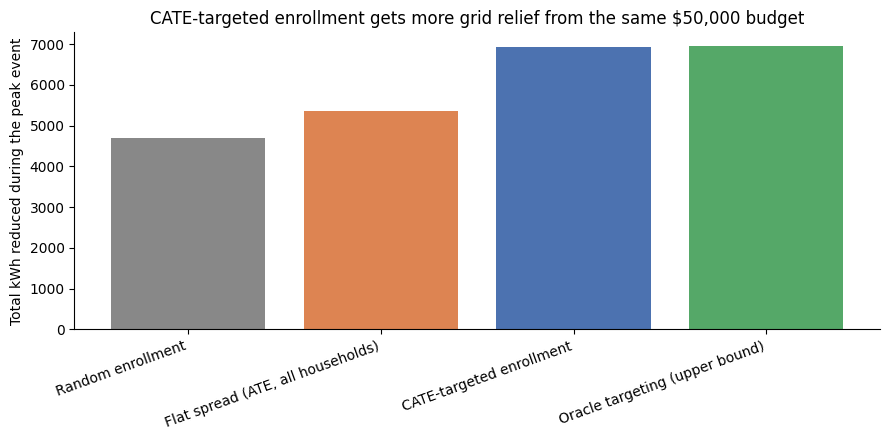

In [13]:

fig, ax = plt.subplots()
colors = ["#888888", "#DD8452", "#4C72B0", "#55A868"]
ax.bar(results["policy"], results["total_kwh_reduced"], color=colors)
ax.set_ylabel("Total kWh reduced during the peak event")
ax.set_title(f"CATE-targeted enrollment gets more grid relief from the same ${budget:,} budget")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()



## 13. Key takeaways

1. **ATE answers "should we run the program?", CATE answers "who should we enroll, and how
   much should we pay them?"** — average $-per-kWh effectiveness is enough for a program
   go/no-go, but targeting needs unit-level heterogeneity.
2. **A model that predicts observed load reduction `Y` is not automatically a model of
   incentive sensitivity** `dY/d$` — our simulation showed these can be only weakly related,
   since baseline behavioral differences are entangled with true price/incentive
   sensitivity.
3. **Regression with treatment-covariate interactions is a simple, effective way to
   estimate CATE**, by differentiating the fitted model (via finite differences) instead of
   trying to regress directly on an unobservable slope target.
4. **CATE can't be validated like an ordinary ML model** (no ground-truth per-household
   label), so we relied on group-level tools: effect-by-quantile, cumulative effect/gain
   curves and their AUC, and target-transformation MSE.
5. **This chapter's "limited supply" guidance is exactly what a real demand-response program
   needs**: with a fixed budget, rank by predicted CATE and enroll the top households — we
   showed this captures most of the achievable grid relief compared to random or flat
   enrollment.

### Where to go next
- Model **incentive amount as a decision variable per household** (not just enrollment
  yes/no) — combine the CATE slope with a cost curve for a full price-optimization problem,
  exactly like the chapter's restaurant pricing example.
- Try nonparametric CATE estimators (causal forests, meta-learners) for a more flexible
  sensitivity model, especially if you suspect the true response function is nonlinear in
  temperature or usage.
- Add a **fairness/equity constraint** (e.g., a minimum enrollment quota for
  lower-income households) and re-solve the allocation problem under that constraint —
  a common real-world requirement for utility demand-response programs.
- Replace the simulated pilot with a real demand-response experiment dataset and rerun this
  entire pipeline unchanged — nothing here is specific to the simulated data.
